**Task 4:- Location-based Analysis.**


*   Objective: Performing a geographical analysis of the
 restaurants in the dataset.





1.    Exploring the latitude and longitude coordinates of
 the restaurants and visualize their distribution on a
 map.
2.   Group the restaurants by city or locality and
 analyze the concentration of restaurants in
 different areas.
3.    Calculate statistics such as the average ratings,
 cuisines, or price ranges by city or locality.
4.   Identify any interesting insights or patterns related
 to the locations of the restaurants.











**Importing necessary libraries.**

In [2]:
import pandas as pd
import folium
import pycountry

In [1]:
!pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 49.9 MB/s eta 0:00:00


**Loading the Dataset**

In [3]:
dataset = pd.read_csv("Dataset.csv")
dataset.head(2)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

**From here our data cleaning process will take place.**


*   First we will find the missing values and then we will handle it!
  



In [5]:
# Filling missing values in 'Cuisines'.
dataset['Cuisines'].fillna('Unknown', inplace=True)

# Droping rows with missing Latitude or Longitude.
dataset.dropna(subset=['Latitude', 'Longitude'], inplace=True)

# We will convert 'Yes'/'No' columns to Boolean making it better for machine to understand.
boolean_columns = ['Has Table booking', 'Has Online delivery', 'Is delivering now']
for col in boolean_columns:
    dataset[col] = dataset[col].apply(lambda x: x == 'Yes')

# Then we will convert 'Price range' and 'Aggregate rating' to numeric and fill missing values in ratings
dataset['Price range'] = pd.to_numeric(dataset['Price range'], errors='coerce')
dataset['Aggregate rating'] = pd.to_numeric(dataset['Aggregate rating'], errors='coerce')
dataset['Aggregate rating'].fillna(dataset['Aggregate rating'].mean(), inplace=True)

<ipython-input-5-32ceff2d33a7>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Cuisines'].fillna('Unknown', inplace=True)
<ipython-input-5-32ceff2d33a7>:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

**By dropping subsets we are ensuring that there are no repeated entries for the same restaurant in the same location.**

In [6]:
dataset.drop_duplicates(subset=['Restaurant Name', 'City', 'Locality'], keep='first', inplace=True)

**Here  our data cleaning processing part is completed.**

**Just for improving the readability we have standardized it.**

In [7]:
dataset['City'] = dataset['City'].str.title()
dataset['Cuisines'] = dataset['Cuisines'].str.title()

In [8]:
# Mapping Country Code to Country Name using pycountry
def get_country_name(code):
    try:
        return pycountry.countries.get(numeric=str(code).zfill(3)).name
    except:
        return 'Unknown'
#The zfill(3) function ensures that the Country Code is always a 3-digit string.
dataset['Country'] = dataset['Country Code'].apply(get_country_name)

**I was still getting unknown values for an entry after initial processing for eg India-8560 instead of India it was showing unknown**

*   Basically it prints the unique list of country codes that remain unresolved.




In [9]:
unknown_country_codes = dataset[dataset['Country'] == 'Unknown']['Country Code'].unique()
print("Unknown Country Codes:", unknown_country_codes)

Unknown Country Codes: [ 30 216  14  37   1  94 215 189]


**The idea behind manually mapping certain country codes is to handle cases
where pycountry might not recognize some codes or return an incorrect or empty result.**

In [10]:
manual_country_mapping = {
    30: "United Arab Emirates",
    216: "United States",
    14: "Australia",
    37: "Canada",
    1: "India",
    94: "Sri Lanka",
    215: "United Kingdom",
    189: "South Africa"
}

# Update unknown country codes
dataset['Country'] = dataset.apply(
    lambda row: manual_country_mapping.get(row['Country Code'], row['Country']),
    axis=1
)


In [11]:
print(dataset['Country'].value_counts())

Country
India                      8560
United States               433
United Kingdom               80
United Arab Emirates         60
Dominican Republic           60
South Africa                 60
Chad                         40
Denmark                      34
Australia                    24
Christmas Island             22
Sri Lanka                    21
Cook Islands                 20
Cocos (Keeling) Islands      20
Croatia                      20
Canada                        4
Name: count, dtype: int64


**The idea behind this is to filter the dataset to include only valid geographical coordinates for latitude and longitude.**

In [12]:
# Setting a valid range for our further analysis.
dataset = dataset[(dataset['Latitude'] >= -90) & (dataset['Latitude'] <= 90) &
                  (dataset['Longitude'] >= -180) & (dataset['Longitude'] <= 180)]

**As India and United States were showing the most resaturants so we focused analysis, comparisons, or insights on data from particular regions of interest, making it easier to work with relevant subsets of data.**

In [13]:
filtered_dataset = dataset[dataset['Country'].isin(['India', 'United States'])]

In [14]:
# Generating our map with the help of folium library
center_lat = filtered_dataset['Latitude'].mean()
center_lon = filtered_dataset['Longitude'].mean()
# By calculating the center latitude and longitude, the map is centered on the average location of these restaurants.
restaurant_map = folium.Map(location=[center_lat, center_lon], zoom_start=4) # providing a visual way to explore restaurant locations and ratings interactively.
for _, row in filtered_dataset.iterrows():
    folium.Marker(
        [row['Latitude'], row['Longitude']],
        popup=f"{row['Restaurant Name']} - Rating: {row['Aggregate rating']}"
    ).add_to(restaurant_map)

**Though the file is not responsive so it takes some time to load, so we focused more on heatmap!**

In [15]:
# Saving the map as an HTML file for review.
restaurant_map.save("restaurant_map_india_us.html")

In [16]:
# Countig the number of restaurants in each city.
city_counts = filtered_dataset.groupby(['Country', 'City']).size().reset_index(name='Restaurant Count')

# Sorting by highest density and displaying the top 10 restaurant counts.
top_cities = city_counts.sort_values(by='Restaurant Count', ascending=False).head(10)
print(top_cities)


   Country          City  Restaurant Count
31   India     New Delhi              5408
15   India       Gurgaon              1109
32   India         Noida              1064
12   India     Faridabad               249
13   India     Ghaziabad                25
1    India     Ahmedabad                21
3    India      Amritsar                21
23   India       Lucknow                21
7    India  Bhubaneshwar                21
16   India      Guwahati                21


In [17]:
# Calculating average ratings and price range by city and country.
city_stats = filtered_dataset.groupby(['Country', 'City']).agg(
    avg_rating=('Aggregate rating', 'mean'),
    avg_price=('Average Cost for two', 'mean')
).reset_index()

# Then we will sort the citites to see cities with the highest average ratings.
top_rated_cities = city_stats.sort_values(by='avg_rating', ascending=False).head(10)
print(top_rated_cities)


          Country            City  avg_rating    avg_price
58  United States         Lincoln    4.500000    25.000000
38          India    Secunderabad    4.500000   825.000000
64  United States         Orlando    4.475000    40.250000
69  United States  Rest Of Hawaii    4.410000    31.750000
72  United States       Tampa Bay    4.410000    34.750000
5           India       Bangalore    4.375000  1232.500000
17          India       Hyderabad    4.344444  1361.111111
9           India         Chennai    4.315000  1085.000000
74  United States        Vernonia    4.300000    10.000000
48  United States      Clatskanie    4.300000    10.000000


**With the help of heatmap we will visually represent restaurant density within the selected countries (India and the United States).**



*   Basically the heatmap shows regions with higher concentrations of restaurants as more intense or "hot" (brighter/red), making it easy to identify areas with a high density of restaurants.






In [18]:
from folium.plugins import HeatMap

# Prepare data for heatmap
heat_data = [[row['Latitude'], row['Longitude']] for index, row in filtered_dataset.iterrows()]

# Now ourInitialize a folium map for the heatmap is getting initialized.
heatmap_map = folium.Map(location=[center_lat, center_lon], zoom_start=4)
HeatMap(heat_data).add_to(heatmap_map)

# Saving the heatmap for review.
heatmap_map.save("restaurant_density_heatmap.html")

In [19]:
# Listing unique cuisines by city.
cuisines_by_city = filtered_dataset.groupby('City')['Cuisines'].apply(lambda x: ', '.join(x.unique())).reset_index()
print(cuisines_by_city.head(10))


         City                                           Cuisines
0        Agra  North Indian, Mughlai, North Indian, Rajasthan...
1   Ahmedabad  Chinese, Italian, North Indian, Mexican, Medit...
2      Albany  Bbq, Burger, Seafood, American, Bbq, Unknown, ...
3   Allahabad  North Indian, South Indian, Fast Food, Cafe, F...
4    Amritsar  North Indian, Chinese, North Indian, Beverages...
5      Athens  American, Southern, Southwestern, Southern, Me...
6     Augusta  Chinese, Steak, American, Caribbean, Seafood, ...
7  Aurangabad  North Indian, Chinese, Continental, Italian, I...
8   Bangalore  North Indian, Mughlai, Asian, Italian, America...
9      Bhopal  Cafe, Chinese, North Indian, Cafe, Fast Food, ...


In [20]:
print(filtered_dataset.head())
print("Number of records in filtered dataset:", len(filtered_dataset))


    Restaurant ID                 Restaurant Name  Country Code    City  \
82       17284404     Austin's BBQ and Oyster Bar           216  Albany   
83       17284203             BJ's Country Buffet           216  Albany   
84       17284105                   Cookie Shoppe           216  Albany   
85       17284302   El Vaquero Mexican Restaurant           216  Albany   
86       17284397  Elements Coffee Co - Northwest           216  Albany   

                                  Address Locality Locality Verbose  \
82     2820 Meredyth Dr, Albany, GA 31707   Albany   Albany, Albany   
83       2401 Dawson Rd, Albany, GA 31707   Albany   Albany, Albany   
84     115 N Jackson St, Albany, GA 31701   Albany   Albany, Albany   
85       2700 Dawson Rd, Albany, GA 31707   Albany   Albany, Albany   
86  2726 Ledo Rd Ste 10, Albany, GA 31707   Albany   Albany, Albany   

    Longitude   Latitude                  Cuisines  ...  Has Table booking  \
82 -84.221535  31.610387      Bbq, Burger, S

In [21]:
# Just printing the first few rows of the original dataset to inspect column names and sample values.
print(dataset.head())
print("Column names:", dataset.columns)


   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

**As you can see this allows for easy identification of top cities in terms of restaurant density.**

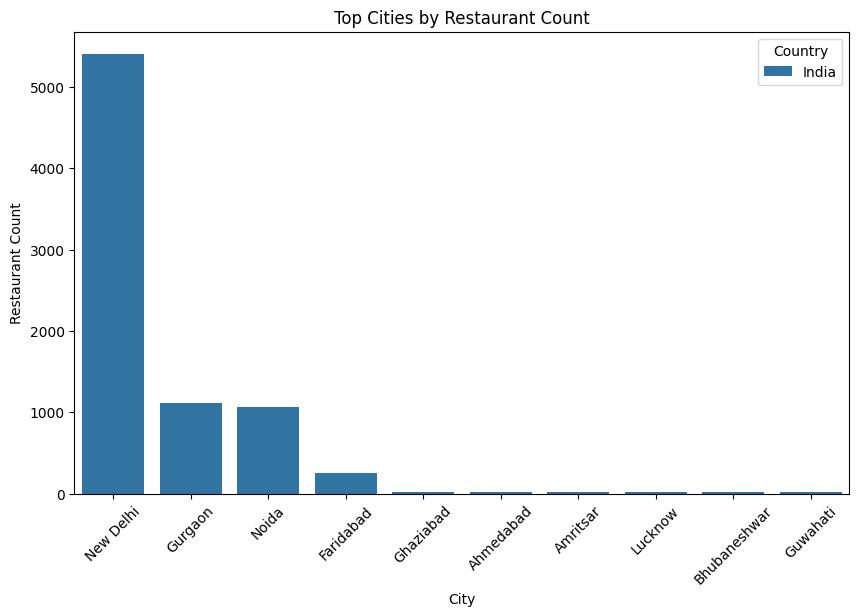

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the top cities by restaurant count.
plt.figure(figsize=(10, 6))
sns.barplot(data=top_cities, x='City', y='Restaurant Count', hue='Country')
plt.xticks(rotation=45)
plt.title("Top Cities by Restaurant Count")
plt.show()


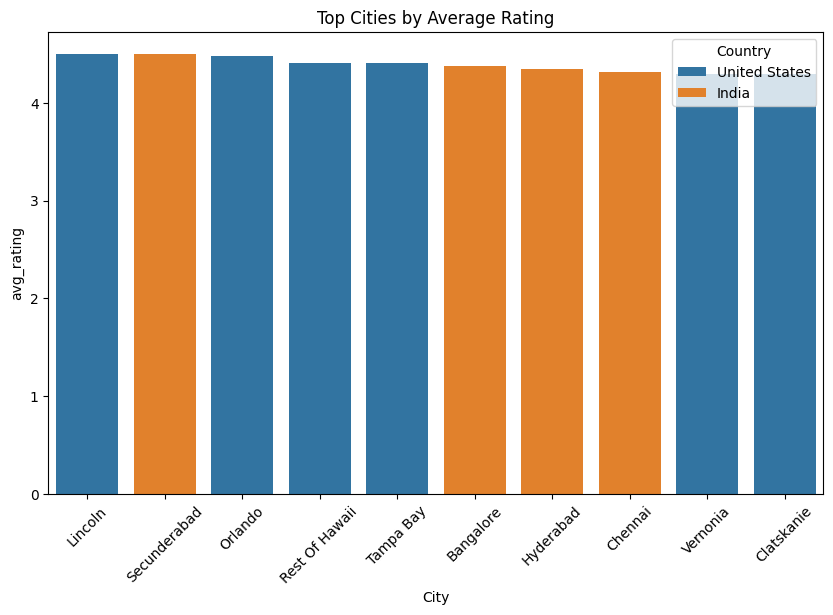

In [23]:
# Plotting average ratings of top-rated cities.
plt.figure(figsize=(10, 6))
sns.barplot(data=top_rated_cities, x='City', y='avg_rating', hue='Country')
plt.xticks(rotation=45)
plt.title("Top Cities by Average Rating")
plt.show()


In [24]:
# Here we are counting occurrences of each cuisine type by city.
cuisine_counts = filtered_dataset.groupby('City')['Cuisines'].apply(lambda x: x.str.split(', ').explode().value_counts().head(5))
print("Top 5 Cuisines by City:")
print(cuisine_counts)


Top 5 Cuisines by City:
City                        
Agra            North Indian    15
                Mughlai          9
                Chinese          6
                Continental      5
                Italian          3
                                ..
Weirton         Greek            1
                Sandwich         1
Winchester Bay  Burger           1
                Seafood          1
                Steak            1
Name: Cuisines, Length: 344, dtype: int64


**Just for checking the top rated cities by restaurant count.**

In [25]:
# Defining the number of items for display (based on the shortest list)
n = 5

# Truncating lists to the first n items
summary_stats = pd.DataFrame({
    "Top Cities by Restaurant Count": top_cities['City'].tolist()[:n],
    "Top-Rated Cities": top_rated_cities['City'].tolist()[:n],
    "Most Common Cuisines in Top Cities": cuisines_by_city['Cuisines'].tolist()[:n]
})

print(summary_stats)


  Top Cities by Restaurant Count Top-Rated Cities  \
0                      New Delhi          Lincoln   
1                        Gurgaon     Secunderabad   
2                          Noida          Orlando   
3                      Faridabad   Rest Of Hawaii   
4                      Ghaziabad        Tampa Bay   

                  Most Common Cuisines in Top Cities  
0  North Indian, Mughlai, North Indian, Rajasthan...  
1  Chinese, Italian, North Indian, Mexican, Medit...  
2  Bbq, Burger, Seafood, American, Bbq, Unknown, ...  
3  North Indian, South Indian, Fast Food, Cafe, F...  
4  North Indian, Chinese, North Indian, Beverages...  
